## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

### Find no.of samples are there in training and test datasets

In [49]:
print(x_train.shape)

(60000, 28, 28)


In [50]:
print("no.of samples in train dataset: ",x_train.shape[0])

no.of samples in train dataset:  60000


In [51]:
print("no.of samples in test dataset: ",x_test.shape[0])

no.of samples in test dataset:  10000


### Find dimensions of an image in the dataset

In [52]:
print("Image Height:",x_train.shape[1])
print("Image Width:",x_train.shape[2])

Image Height: 28
Image Width: 28


### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
import tensorflow as tf

In [0]:
trainY = tf.keras.utils.to_categorical(y_train,num_classes=10)

In [0]:
testY = tf.keras.utils.to_categorical(y_test,num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
x_train=x_train.reshape((x_train.shape[0],28,28,1))
x_test=x_test.reshape((x_test.shape[0],28,28,1))

In [58]:
x_train.shape

(60000, 28, 28, 1)

In [59]:
x_test.shape

(10000, 28, 28, 1)

### Import the necessary layers from keras to build the model

In [0]:
from tensorflow.python.keras import Sequential
model = tf.keras.models.Sequential()

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
#model.add(tf.keras.layers.BatchNormalization(input_shape=(img_size,img_size,3,)))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))


In [0]:
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1, mode='min')


In [63]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train,trainY,          
          validation_data=(x_test,testY),
          epochs=10,
          batch_size=32,callbacks=[early_stop])

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 8s 141us/sample - loss: 0.3740 - acc: 0.8652 - val_loss: 0.2882 - val_acc: 0.8938
Epoch 2/10
60000/60000 [==============================] - 8s 135us/sample - loss: 0.2325 - acc: 0.9145 - val_loss: 0.2506 - val_acc: 0.9106
Epoch 3/10
60000/60000 [==============================] - 8s 134us/sample - loss: 0.1658 - acc: 0.9389 - val_loss: 0.2602 - val_acc: 0.9087
Epoch 4/10
60000/60000 [==============================] - 8s 133us/sample - loss: 0.1167 - acc: 0.9569 - val_loss: 0.2951 - val_acc: 0.9075
Epoch 5/10
60000/60000 [==============================] - 8s 133us/sample - loss: 0.0769 - acc: 0.9711 - val_loss: 0.3122 - val_acc: 0.9093
Epoch 6/10
60000/60000 [==============================] - 8s 133us/sample - loss: 0.0515 - acc: 0.9818 - val_loss: 0.3490 - val_acc: 0.9149
Epoch 7/10
60000/60000 [==============================] - 8s 133us/sample - loss: 0.0372 - acc: 0.9861 - val_l

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
model1 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model1.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model1.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model1.add(tf.keras.layers.Dropout(0.25))
model1.add(tf.keras.layers.Flatten())
model1.add(tf.keras.layers.Dense(128, activation='relu'))
#Output layer
model1.add(tf.keras.layers.Dense(10, activation='softmax'))


In [0]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True)

In [0]:
batch_size=64
train_generator = data_generator.flow(x_train,trainY,batch_size=batch_size)
test_generator = data_generator.flow(x_test,testY,batch_size=batch_size)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

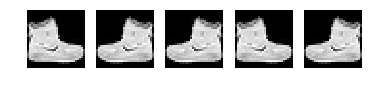

In [73]:
from matplotlib import pyplot as plt
gen = data_generator.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [72]:

model1.fit_generator(train_generator, 
                          epochs=10,
                          validation_data=test_generator)

Epoch 1/10
938/938 [==============================] - 7s 7ms/step - loss: 0.4493 - acc: 0.7794 - val_loss: 0.3296 - val_acc: 0.8799
Epoch 2/10
938/938 [==============================] - 6s 6ms/step - loss: 0.2952 - acc: 0.8924 - val_loss: 0.2901 - val_acc: 0.8932
Epoch 3/10
938/938 [==============================] - 6s 6ms/step - loss: 0.2524 - acc: 0.9050 - val_loss: 0.2588 - val_acc: 0.9057
Epoch 4/10
938/938 [==============================] - 6s 6ms/step - loss: 0.2218 - acc: 0.9178 - val_loss: 0.2385 - val_acc: 0.9112
Epoch 5/10
938/938 [==============================] - 6s 6ms/step - loss: 0.1995 - acc: 0.9263 - val_loss: 0.2482 - val_acc: 0.9085
Epoch 6/10
938/938 [==============================] - 6s 7ms/step - loss: 0.1794 - acc: 0.9342 - val_loss: 0.2264 - val_acc: 0.9169
Epoch 7/10
938/938 [==============================] - 6s 6ms/step - loss: 0.1650 - acc: 0.9401 - val_loss: 0.2206 - val_acc: 0.9245
Epoch 8/10
938/938 [==============================] - 6s 6ms/step - loss: 0.

###  Report the final train and validation accuracy

In [28]:
model1.evaluate(x_test,testY,verbose=1)

10000/10000 [==============================] - 1s 75us/sample - loss: 0.2886 - acc: 0.9227


[0.28860901135466993, 0.9227]

In [29]:
model1.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            multiple                  320       
_________________________________________________________________
conv2d_3 (Conv2D)            multiple                  9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) multiple                  0         
_________________________________________________________________
dropout (Dropout)            multiple                  0         
_________________________________________________________________
flatten_1 (Flatten)          multiple                  0         
_________________________________________________________________
dense_2 (Dense)              multiple                  589952    
_________________________________________________________________
dense_3 (Dense)              multiple                 

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
from keras.datasets import cifar10


### **Load CIFAR10 dataset**

In [0]:
(x_train_cifar10, y_train_cifar10), (x_test_cifar10, y_test_cifar10) = cifar10.load_data()

In [75]:
print("train data size: ",x_train_cifar10.shape[0])

train data size:  50000


In [76]:
print("test data size: ",x_test_cifar10.shape[0])

test data size:  10000


In [77]:
print("Image Height:",x_train_cifar10.shape[1])
print("Image Width:",x_train_cifar10.shape[2])

Image Height: 32
Image Width: 32


### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
data_cifar10_generator = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True,
                                                               width_shift_range=0.2,
                                                               height_shift_range=0.2,
                                                               rotation_range=30)

### **Prepare/fit the generator.**

In [0]:
data_cifar10_generator.fit(x_train_cifar10)

In [34]:
x_train_cifar10.shape

(50000, 32, 32, 3)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

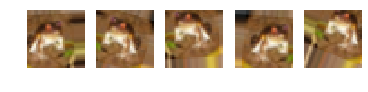

In [36]:
from matplotlib import pyplot as plt
import numpy as np
gen = data_cifar10_generator.flow(x_train_cifar10[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().astype(np.uint8).squeeze())
    plt.plot()
plt.show()